In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
results_path = "/home/mahmoud/projects/RegionAwareVisionAssistant/results/EfficientAd/MVTecAD/leather/leather_test_scores.json"

with open(results_path, "r") as f:
    results = json.load(f)

test_df = pd.DataFrame(results)
test_df['image_name'] = test_df['image_path'].apply(lambda x: '_'.join(x.split('/')[-3:]))
test_df['anomaly_category'] = test_df['image_name'].apply(lambda x: x.split('_')[1])
test_df.head()

,image_path,gt_label,pred_score,pred_label,image_name,anomaly_category
0,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.649756,True,test_color_000.png,color
1,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.509071,True,test_color_001.png,color
2,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.524326,True,test_color_002.png,color
3,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.515668,True,test_color_003.png,color
4,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.504016,True,test_color_004.png,color


F1: 0.9577464788732394
Precision: 1.0
Recall: 0.918918918918919


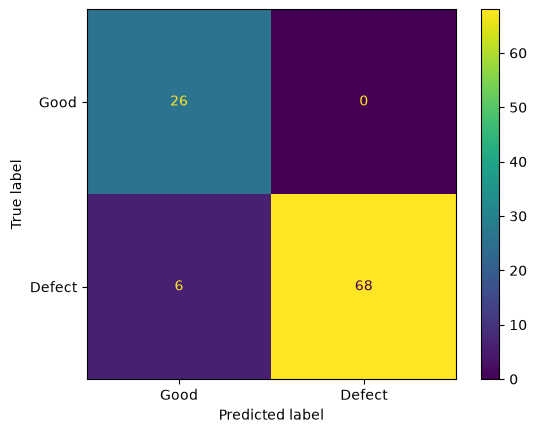

In [5]:
best_threshold = 0.504636824131012
test_df['pred_label_calibrated'] = test_df['pred_score'] >= best_threshold

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

cm = confusion_matrix(test_df['gt_label'], test_df['pred_label_calibrated'])
ConfusionMatrixDisplay(cm, display_labels=['Good', 'Defect']).plot()

print("F1:", f1_score(test_df['gt_label'], test_df['pred_label_calibrated']))
print("Precision:", precision_score(test_df['gt_label'], test_df['pred_label_calibrated']))
print("Recall:", recall_score(test_df['gt_label'], test_df['pred_label_calibrated']))